# Monte Carlo Kernel Benchmarking

This notebook performs a comprehensive performance evaluation of different OpenCL kernels implemented for the Monte Carlo simulation. We compare the **Standard 1D**, **Ping-Pong**, **Cascading**, **2D Grid-Stride**, and **2D Ping-Pong** approaches across various metrics, including execution time, memory bandwidth, VRAM footprint, and throughput.

**Bandwidth metric.** The reported *Effective Bandwidth* is computed as `(n_runs × n_cells × 4 + n_wg × 4) / time` (canonical effective-bandwidth convention: every global-memory load/store instruction is counted at face value, regardless of cache hits). Because `p_vec` (~600 KB for this habitat) fits in the GPU's L2 cache, the measured values can exceed the device's DRAM peak (the 4050 is ~190-270 GB/s) — in that regime the metric reflects cache→SM throughput, not VRAM→SM.

## Environment Setup

Loading environment variables and importing necessary modules for the simulation and data analysis.

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from dotenv import load_dotenv

from pyroclast import (
    FileMapRepository,
    HabitatCriteria,
    PyOpenCLAdapter,
    PyOpenCLMonteCarloAdapter,
    PyOpenCLMonteCarloPingPongAdapter,
    PyOpenCLMonteCarloCascadingAdapter,
    PyOpenCLMonteCarlo2DAdapter,
    PyOpenCLMonteCarlo2DPingPongAdapter,
)
from pyroclast.domain.models import MonteCarloConfig
from pyroclast.services import run_preprocessing_batch

load_dotenv()
data_path = os.getenv("DATA_PATH", "data").strip('"\'')
cache_dir = Path(os.getenv("CACHE_DIR", str(Path(data_path) / "cache")).strip('"\''))

## Data Preparation

Running the preprocessing pipeline to obtain the compacted habitat data required for the Monte Carlo simulation.

In [2]:
repo = FileMapRepository(data_path)
preprocess_adapter = PyOpenCLAdapter()
compacted = run_preprocessing_batch(
    repo=repo,
    compute=preprocess_adapter,
    criteria=HabitatCriteria(),
    cache_dir=cache_dir,
)
target_habitat = compacted[0]
print(f"Selected Habitat: {target_habitat.habitat_code} ({target_habitat.n_cells} cells)")

pci id for fd 83: 10de:28e1, driver (null)
pci id for fd 84: 10de:28e1, driver (null)


Selected Habitat: 4090 (153989 cells)


## Phase 1: Single-Shot Performance Analysis

Executing a single benchmark run with a high number of simulations (1,000,000) for all kernels to collect detailed performance metrics including VRAM footprint and speedup.

In [3]:
MC_RUNS = 1_000_000
THRESHOLD = 0.005
SEED = 42
N_BATCHES = 10

kernels_to_bench = [
    {"name": "Standard",    "adapter": PyOpenCLMonteCarloAdapter(profiling=True)},
    {"name": "Ping-Pong",   "adapter": PyOpenCLMonteCarloPingPongAdapter(profiling=True)},
    {"name": "Cascading",   "adapter": PyOpenCLMonteCarloCascadingAdapter(profiling=True)},
    {"name": "2D-Stride",   "adapter": PyOpenCLMonteCarlo2DAdapter(profiling=True)},
    {"name": "2D-PingPong", "adapter": PyOpenCLMonteCarlo2DPingPongAdapter(profiling=True)},
]

config = MonteCarloConfig(n_runs=MC_RUNS, threshold=THRESHOLD, seed=SEED)
phase1_data = []

print(f"Running Phase 1 Benchmark (R={MC_RUNS:,}, Batches={N_BATCHES})...")
for k in kernels_to_bench:
    adapter = k["adapter"]
    adapter.reset_profile()
    adapter.run(target_habitat, config)
    bench = adapter.benchmark()[0]

    total_time_ms = bench.mean_ms * N_BATCHES
    throughput = MC_RUNS / (total_time_ms / 1000.0)

    phase1_data.append({
        "Kernel": k["name"],
        "Time (ms)": total_time_ms,
        "Bandwidth (GB/s)": bench.bandwidth_gbs,
        "VRAM (MB)": bench.memory_mb,
        "Throughput (Sim/s)": throughput
    })

df_phase1 = pd.DataFrame(phase1_data)
std_time = df_phase1[df_phase1["Kernel"] == "Standard"]["Time (ms)"].values[0]
df_phase1["Speedup"] = std_time / df_phase1["Time (ms)"]

print("\nPhase 1 Results:")
display(df_phase1.style.format({
    "Time (ms)": "{:.2f}",
    "Bandwidth (GB/s)": "{:.1f}",
    "VRAM (MB)": "{:.2f}",
    "Throughput (Sim/s)": "{:.0f}",
    "Speedup": "{:.2f}x"
}))

Running Phase 1 Benchmark (R=1,000,000, Batches=10)...

Phase 1 Results:


,Kernel,Time (ms),Bandwidth (GB/s),VRAM (MB),Throughput (Sim/s),Speedup
0,Standard,5704.78,1079.7,0.62,175292,1.00x
1,Ping-Pong,5685.15,1083.4,0.62,175897,1.00x
2,Cascading,5694.24,1081.7,0.62,175616,1.00x
3,2D-Stride,5531.00,1113.6,0.62,180799,1.03x
4,2D-PingPong,5532.18,1113.4,0.62,180761,1.03x


## Phase 2: Scaling and Throughput Analysis

Performing a parametric sweep from 100,000 to 2,000,000 simulations (with 100,000 increments) to observe the scalability of each kernel and how metrics like effective bandwidth and throughput behave under increasing load.

In [4]:
RUNS_MIN = 1_000_000
RUNS_MAX = 2_000_000
INCREMENT = 100_000
N_BATCHES_SCALING = 1

run_sizes = list(range(RUNS_MIN, RUNS_MAX + 1, INCREMENT))
results_scaling = {k["name"]: [] for k in kernels_to_bench}
bandwidths_scaling = {k["name"]: [] for k in kernels_to_bench}
throughputs_scaling = {k["name"]: [] for k in kernels_to_bench}

print("Running Phase 2 Scaling Benchmark...")
for runs in run_sizes:
    config = MonteCarloConfig(n_runs=runs, threshold=THRESHOLD, seed=SEED)
    for k in kernels_to_bench:
        adapter = k["adapter"]
        adapter.reset_profile()
        adapter.run_batched(target_habitat, config, N_BATCHES_SCALING)
        bench = adapter.benchmark()[0]
        
        total_time_ms = bench.mean_ms * N_BATCHES_SCALING
        throughput = runs / (total_time_ms / 1000.0)
        
        results_scaling[k["name"]].append(total_time_ms)
        bandwidths_scaling[k["name"]].append(bench.bandwidth_gbs)
        throughputs_scaling[k["name"]].append(throughput)
    print(f"  Completed R={runs:,}", end="\r")
print("\nScaling benchmark completed.")

Running Phase 2 Scaling Benchmark...
  Completed R=2,000,000
Scaling benchmark completed.


## Visualization of Results

Plotting the scaling results to compare absolute execution times, standardized deviations, effective memory bandwidth, and computational throughput.

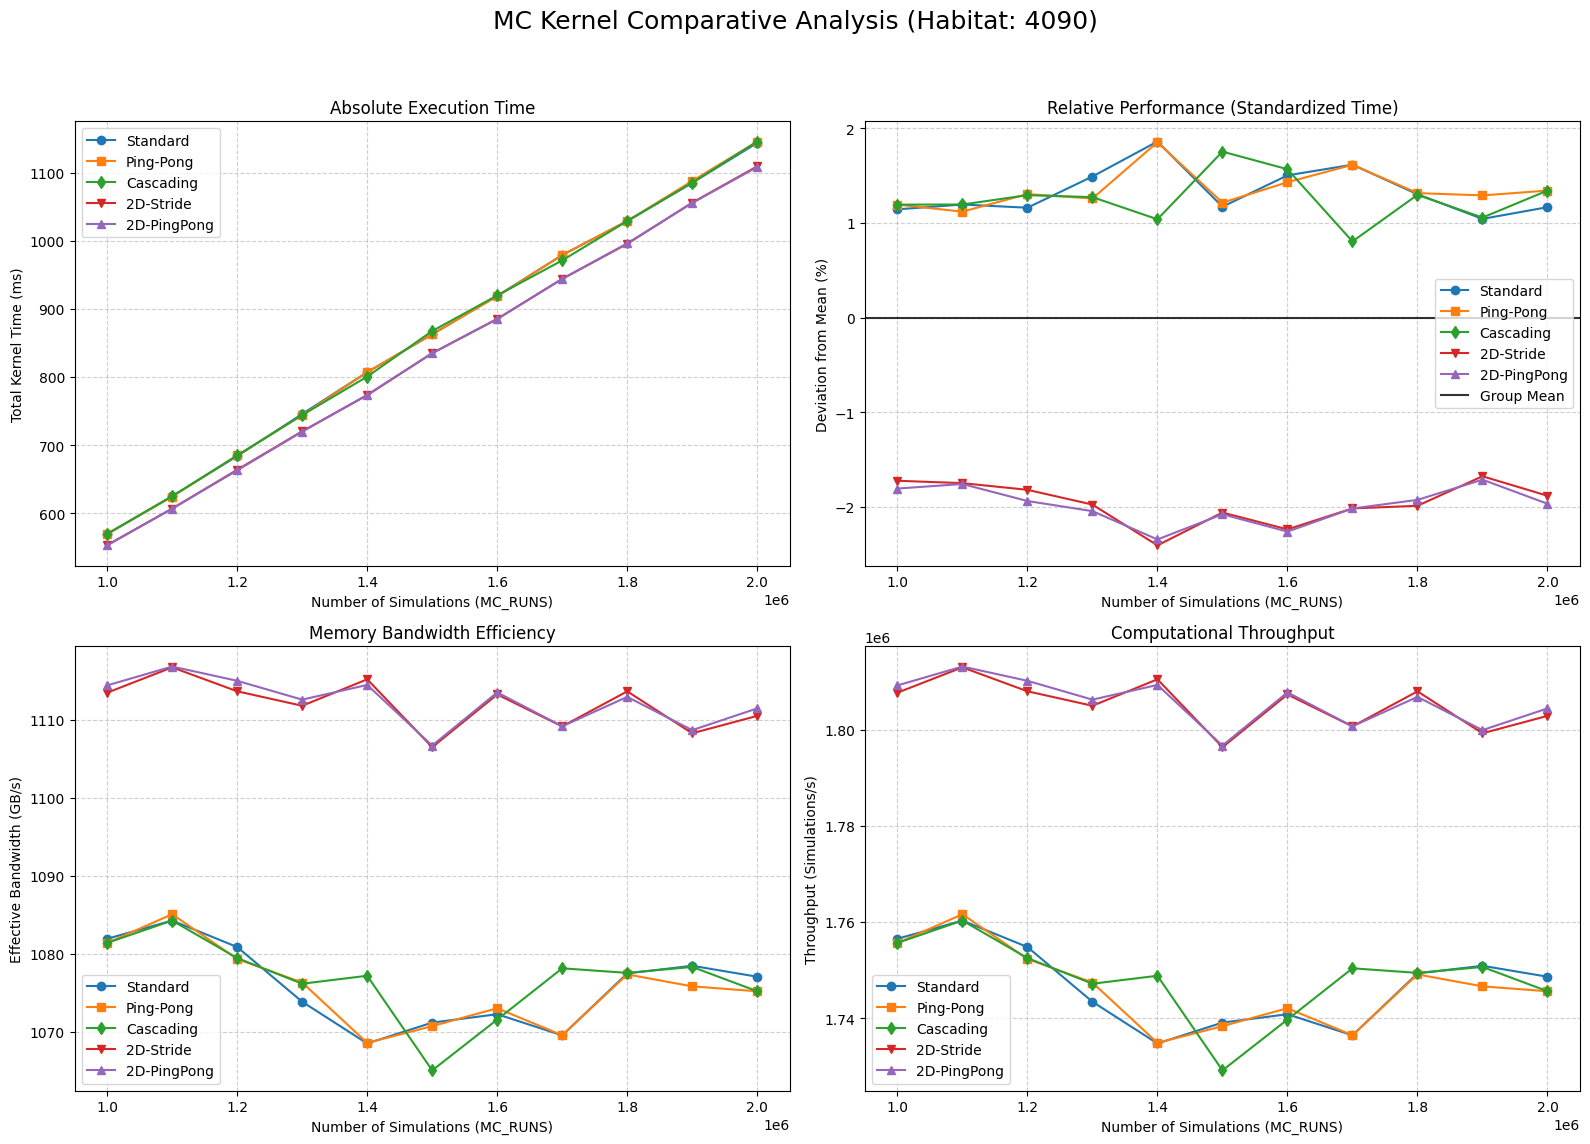

In [5]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

colors = {
    "Standard":    "#1f77b4",
    "Ping-Pong":   "#ff7f0e",
    "Cascading":   "#2ca02c",
    "2D-Stride":   "#d62728",
    "2D-PingPong": "#9467bd",
}
markers = {
    "Standard":    "o",
    "Ping-Pong":   "s",
    "Cascading":   "d",
    "2D-Stride":   "v",
    "2D-PingPong": "^",
}

all_times = np.array([results_scaling[k["name"]] for k in kernels_to_bench])
mean_times = np.mean(all_times, axis=0)

# Subplot 1: Absolute Time
for k in kernels_to_bench:
    name = k["name"]
    ax1.plot(run_sizes, results_scaling[name], marker=markers[name], label=name, color=colors[name])
ax1.set_xlabel("Number of Simulations (MC_RUNS)")
ax1.set_ylabel("Total Kernel Time (ms)")
ax1.set_title("Absolute Execution Time")
ax1.grid(True, linestyle="--", alpha=0.6)
ax1.legend()

# Subplot 2: Standardized Time (% deviation from mean)
for k in kernels_to_bench:
    name = k["name"]
    pct_deviation = (np.array(results_scaling[name]) / mean_times - 1) * 100
    ax2.plot(run_sizes, pct_deviation, marker=markers[name], label=name, color=colors[name])
ax2.axhline(0.0, color='black', linestyle='-', alpha=0.8, label='Group Mean')
ax2.set_xlabel("Number of Simulations (MC_RUNS)")
ax2.set_ylabel("Deviation from Mean (%)")
ax2.set_title("Relative Performance (Standardized Time)")
ax2.grid(True, linestyle="--", alpha=0.6)
ax2.legend()

# Subplot 3: Effective Bandwidth
for k in kernels_to_bench:
    name = k["name"]
    ax3.plot(run_sizes, bandwidths_scaling[name], marker=markers[name], label=name, color=colors[name])
ax3.set_xlabel("Number of Simulations (MC_RUNS)")
ax3.set_ylabel("Effective Bandwidth (GB/s)")
ax3.set_title("Memory Bandwidth Efficiency")
ax3.grid(True, linestyle="--", alpha=0.6)
ax3.legend()

# Subplot 4: Throughput
for k in kernels_to_bench:
    name = k["name"]
    ax4.plot(run_sizes, throughputs_scaling[name], marker=markers[name], label=name, color=colors[name])
ax4.set_xlabel("Number of Simulations (MC_RUNS)")
ax4.set_ylabel("Throughput (Simulations/s)")
ax4.set_title("Computational Throughput")
ax4.grid(True, linestyle="--", alpha=0.6)
ax4.legend()

plt.suptitle(f"MC Kernel Comparative Analysis (Habitat: {target_habitat.habitat_code})", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()